## Recommendation System with Business Analytics
### Movie Recommendation System using Machine Learning and Business Analytics
#### Project Objectives
Analyze movie and user rating data.
Build popularity-based recommendations.
Build content-based recommendations.
Generate business insights.
Create an interactive Streamlit app.
Deploy the application.
Document the project professionally.

### Import Libraries

In [203]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


### Load the Dataset

In [8]:
movies = pd.read_csv("../data/movies.csv")
ratings = pd.read_csv("../data/ratings.csv")

In [9]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [10]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [11]:
# checking the dataset size
movies.shape

(9742, 3)

In [12]:
ratings.shape

(100836, 4)

In [13]:
# Inspecting the columns
movies.columns

Index(['movieId', 'title', 'genres'], dtype='object')

In [14]:
ratings.columns

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')

In [15]:
# Checking Data Types
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [16]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [17]:
# checking the missing values
movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In [18]:
ratings.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [19]:
# No any null values so i think we dont need to remove the missing values 

In [20]:
# verify cleaning the both the movies and the rating data
movies.shape
ratings.shape

(100836, 4)

## Exploratory Data Analysis(EDA)

### Understand:

Rating patterns

Popular movies

Active users

Genre distribution

Business insights

In [23]:
### Merge the database (movies and ratings)
movies = pd.read_csv("../data/movies.csv")
ratings = pd.read_csv("../data/ratings.csv")

movie_data = pd.merge(
    ratings,
    movies,
    on="movieId",
 
)

movie_data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [24]:
movie_data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [25]:
movie_data.shape

(100836, 6)

In [26]:
movie_data.describe()

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


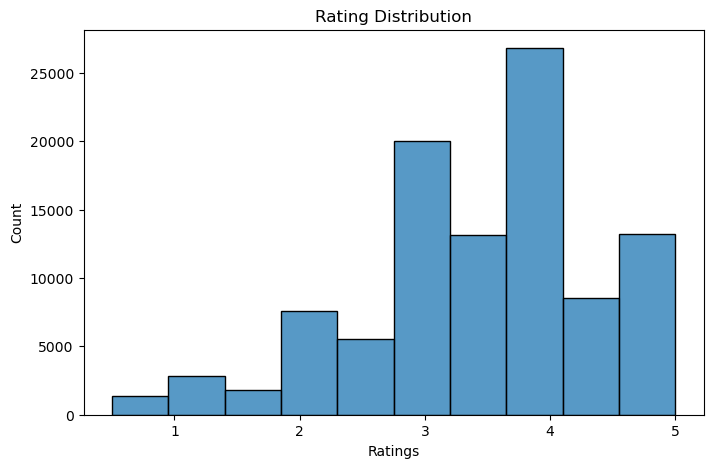

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(movie_data['rating'], bins=10)

plt.title("Rating Distribution")

plt.xlabel("Ratings")

plt.ylabel("Count")

plt.show()


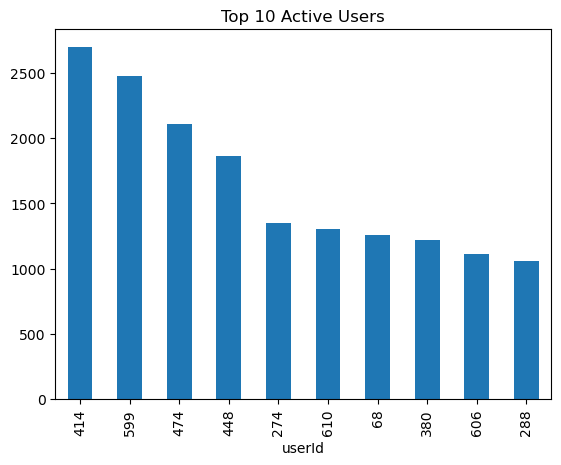

In [28]:
# Most Active users
movie_data['userId'].value_counts().head()
movie_data['userId'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Active Users")

plt.show()

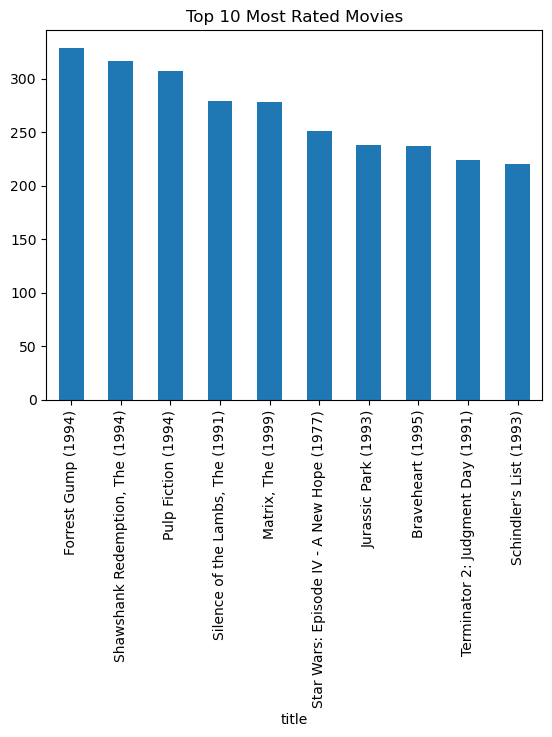

In [29]:
# Most Rated movies
movie_data.groupby('title')['rating'].count().sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Top 10 Most Rated Movies")

plt.show()

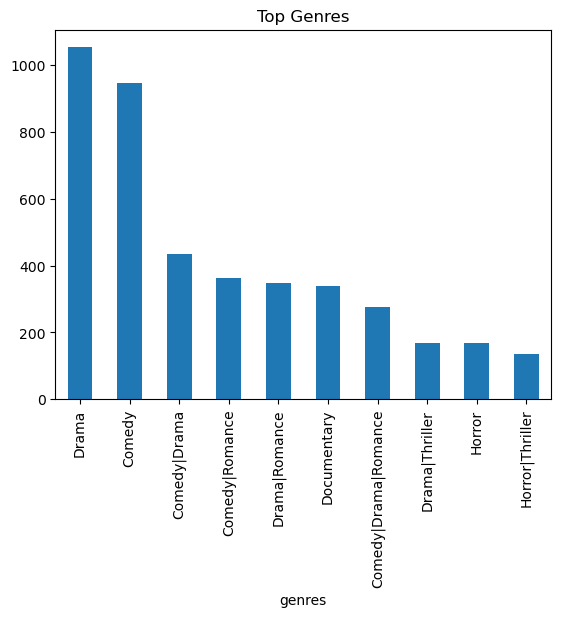

In [30]:
# Genre distribution
movies['genres'].value_counts().head(10).plot(kind='bar')

plt.title("Top Genres")

plt.show()


In [31]:
# Average Rating per movie
avg_rating = movie_data.groupby('title')['rating'].mean()
avg_rating.head()

title
'71 (2014)                                 4.0
'Hellboy': The Seeds of Creation (2004)    4.0
'Round Midnight (1986)                     3.5
'Salem's Lot (2004)                        5.0
'Til There Was You (1997)                  4.0
Name: rating, dtype: float64

In [32]:
# NUmber of rating per movie
rating_count = movie_data.groupby('title')['rating'].count()

In [33]:
# combine stats
movie_stats = pd.DataFrame({
    'Average Rating': avg_rating,
    'Rating Count': rating_count
})

movie_stats.head()

,Average Rating,Rating Count
title,,
'71 (2014),4.0,1
'Hellboy': The Seeds of Creation (2004),4.0,1
'Round Midnight (1986),3.5,2
'Salem's Lot (2004),5.0,1
'Til There Was You (1997),4.0,2


In [34]:
# Top popular movies
movie_stats.sort_values(
    by='Rating Count',
    ascending=False
).head(10)

,Average Rating,Rating Count
title,,
Forrest Gump (1994),4.164134,329
"Shawshank Redemption, The (1994)",4.429022,317
Pulp Fiction (1994),4.197068,307
"Silence of the Lambs, The (1991)",4.161290,279
"Matrix, The (1999)",4.192446,278
Star Wars: Episode IV - A New Hope (1977),4.231076,251
Jurassic Park (1993),3.750000,238
Braveheart (1995),4.031646,237
Terminator 2: Judgment Day (1991),3.970982,224


In [35]:
# Correlation heatmap
numeric_data = movie_data.select_dtypes(include=np.number)

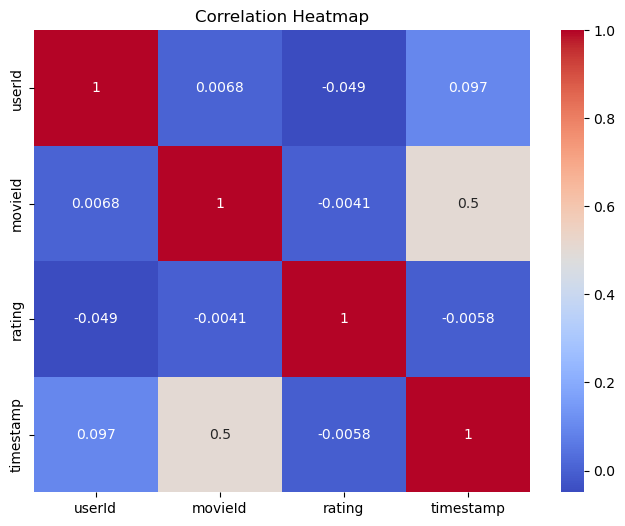

In [36]:
# HeatMap
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [37]:
# TOp 10 movies by average rating 
popular = movie_stats[
    movie_stats['Rating Count'] >= 50
]

popular.sort_values(
    by='Average Rating',
    ascending=False
).head(10)

,Average Rating,Rating Count
title,,
"Shawshank Redemption, The (1994)",4.429022,317
"Godfather, The (1972)",4.289062,192
Fight Club (1999),4.272936,218
Cool Hand Luke (1967),4.271930,57
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964),4.268041,97
Rear Window (1954),4.261905,84
"Godfather: Part II, The (1974)",4.259690,129
"Departed, The (2006)",4.252336,107
Goodfellas (1990),4.250000,126


## Features
Movie statistics

User-Movie Matrix

Popularity Score

Top Movies Recommendation

These features will later help build the content-based recommender.

### Creatign movie stats


In [38]:
# Average Rating
avg_rating = movie_data.groupby("title")["rating"].mean()
avg_rating.head()

title
'71 (2014)                                 4.0
'Hellboy': The Seeds of Creation (2004)    4.0
'Round Midnight (1986)                     3.5
'Salem's Lot (2004)                        5.0
'Til There Was You (1997)                  4.0
Name: rating, dtype: float64

In [39]:
# Rating count
rating_count = movie_data.groupby("title")["rating"].count()
rating_count.head().sum()

np.int64(7)

In [40]:
movie_stats = pd.DataFrame({
    "Average Rating":avg_rating,
    "Rating Count":rating_count
})

In [41]:
movie_stats.head()

,Average Rating,Rating Count
title,,
'71 (2014),4.0,1
'Hellboy': The Seeds of Creation (2004),4.0,1
'Round Midnight (1986),3.5,2
'Salem's Lot (2004),5.0,1
'Til There Was You (1997),4.0,2


In [42]:
popular_movies = movie_stats[
    movie_stats["Rating Count"]>=50
]

In [43]:
popular_movies.sort_values(
    by="Average Rating",
    ascending=False
).head(10)

,Average Rating,Rating Count
title,,
"Shawshank Redemption, The (1994)",4.429022,317
"Godfather, The (1972)",4.289062,192
Fight Club (1999),4.272936,218
Cool Hand Luke (1967),4.271930,57
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964),4.268041,97
Rear Window (1954),4.261905,84
"Godfather: Part II, The (1974)",4.259690,129
"Departed, The (2006)",4.252336,107
Goodfellas (1990),4.250000,126


In [44]:
## Creating user-Movie matrix
movie_matrix = movie_data.pivot_table(
    index="userId",
    columns="title",
    values="rating"
)

In [45]:
movie_matrix.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
movie_matrix.shape

(610, 9719)

In [47]:
movie_matrix.isnull().sum()  # There are number of non ratied movies

title
'71 (2014)                                   609
'Hellboy': The Seeds of Creation (2004)      609
'Round Midnight (1986)                       608
'Salem's Lot (2004)                          609
'Til There Was You (1997)                    608
                                            ... 
eXistenZ (1999)                              588
xXx (2002)                                   586
xXx: State of the Union (2005)               605
¡Three Amigos! (1986)                        584
À nous la liberté (Freedom for Us) (1931)    609
Length: 9719, dtype: int64

In [48]:
# Fill the missing values 
movie_matrix.fillna(0, inplace = True) # filld the missing values with the 0

In [49]:
# Most active users 
user_activity = movie_data.groupby('userId')['rating'].count()

In [50]:
user_activity.sort_values(ascending = True).head()

userId
442    20
406    20
147    20
194    20
569    20
Name: rating, dtype: int64

In [51]:
# Movie popularity score
movie_stats["Popularity Score"] = (
movie_stats["Average Rating"]
*
movie_stats["Rating Count"]
)

In [52]:
movie_stats.head()

,Average Rating,Rating Count,Popularity Score
title,,,
'71 (2014),4.0,1,4.0
'Hellboy': The Seeds of Creation (2004),4.0,1,4.0
'Round Midnight (1986),3.5,2,7.0
'Salem's Lot (2004),5.0,1,5.0
'Til There Was You (1997),4.0,2,8.0


In [53]:
# Top Popular Moveis
movie_stats.sort_values(
    by = "Popularity Score",
    ascending = False
).head(10)

,Average Rating,Rating Count,Popularity Score
title,,,
"Shawshank Redemption, The (1994)",4.429022,317,1404.0
Forrest Gump (1994),4.164134,329,1370.0
Pulp Fiction (1994),4.197068,307,1288.5
"Matrix, The (1999)",4.192446,278,1165.5
"Silence of the Lambs, The (1991)",4.161290,279,1161.0
Star Wars: Episode IV - A New Hope (1977),4.231076,251,1062.0
Braveheart (1995),4.031646,237,955.5
Fight Club (1999),4.272936,218,931.5
Schindler's List (1993),4.225000,220,929.5


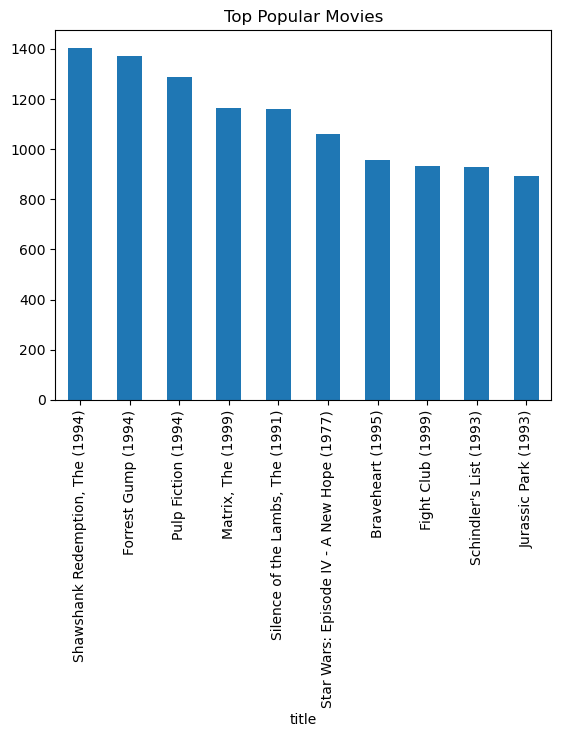

In [54]:
# visulation of the data 

movie_stats.sort_values(
by="Popularity Score",
ascending=False
).head(10)["Popularity Score"].plot(
kind="bar"
)

plt.title(
"Top Popular Movies"
)

plt.show()

In [55]:
movies["genres"].value_counts().head(10)

genres
Drama                   1053
Comedy                   946
Comedy|Drama             435
Comedy|Romance           363
Drama|Romance            349
Documentary              339
Comedy|Drama|Romance     276
Drama|Thriller           168
Horror                   167
Horror|Thriller          135
Name: count, dtype: int64

## Content-Based Recommendation System (Core ML Part)
"If a user likes Movie A, what other similar movies should we recommend?"

We'll use:

TF-IDF

Cosine Similarity

Recommendation Function

In [57]:
# Checking for missing Genres
movies["genres"].isnull().sum()

np.int64(0)

In [76]:
# Import Required library
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics.pairwise import cosine_similarity

In [83]:
# Machine Learning cannot understand the text so we are using thye TF - IDF to covert the text to the numbers 
# Create TF-IDF object

In [84]:
# It prepare a converter that taransform the movies generes into numeric vectors
# Convert Genres
tfidf = TfidfVectorizer(stop_words="english")

In [85]:
tfidf_matrix = tfidf.fit_transform(movies["genres"])

In [87]:
tfidf_matrix.shape

(9742, 23)

In [90]:
# Calculate Similarity
cosine_sim = cosine_similarity(
    tfidf_matrix,
    tfidf_matrix
)

In [92]:
# Create MOvie index
indices = pd.Series(
    movies.index,
    index=movies["title"]
)

In [93]:
# Remove the Duplicate titles
indices = indices[
    ~indices.index.duplicated(
        keep="first"
    )
]

## Build Recommendation Function
#### Complete function

In [94]:
def recommend_movies(movie_name):

    if movie_name not in indices:
        return "Movie not found."

    idx = indices[movie_name]

    similarity_scores = list(
        enumerate(
            cosine_sim[idx]
        )
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x:x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:6]

    movie_indices = [
        i[0]
        for i in similarity_scores
    ]

    return movies[
        "title"
    ].iloc[
        movie_indices
    ]

In [98]:
# TEst the model
recommend_movies(
"Toy Story (1995)"
)

1706                                       Antz (1998)
2355                                Toy Story 2 (1999)
2809    Adventures of Rocky and Bullwinkle, The (2000)
3000                  Emperor's New Groove, The (2000)
3568                             Monsters, Inc. (2001)
Name: title, dtype: object

In [99]:
recommend_movies(
    "Jumanji (1995)"
)

53             Indian in the Cupboard, The (1995)
109             NeverEnding Story III, The (1994)
767               Escape to Witch Mountain (1975)
1514    Darby O'Gill and the Little People (1959)
1556                          Return to Oz (1985)
Name: title, dtype: object

# Hybrid Recommendation System + Model Evaluation
 Data Cleaning
 
 EDA
 
 Business Analytics
 
 Popularity-Based Recommendation
 
 Content-Based Recommendation

In [102]:
# Calculating average rating 
avg_rating  = movie_data.groupby("title")["rating"].mean()

In [103]:
# Calculating rating counts
rating_count = movie_data.groupby("title")["rating"].count()

In [104]:
# Creating a stastic table
movie_stats = pd.DataFrame({
    "Average Rating": avg_rating,
    "Rating count": rating_count
})

In [105]:
movie_stats.head()

,Average Rating,Rating count
title,,
'71 (2014),4.0,1
'Hellboy': The Seeds of Creation (2004),4.0,1
'Round Midnight (1986),3.5,2
'Salem's Lot (2004),5.0,1
'Til There Was You (1997),4.0,2


In [108]:
#Merge the stats
movies = movies.merge(movie_stats,
                     on = "title",
                     how = "left"
)

In [110]:
movies.head()

,movieId,title,genres,Average Rating,Rating count
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,3.920930,215.0
1,2,Jumanji (1995),Adventure|Children|Fantasy,3.431818,110.0
2,3,Grumpier Old Men (1995),Comedy|Romance,3.259615,52.0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,2.357143,7.0
4,5,Father of the Bride Part II (1995),Comedy,3.071429,49.0


In [111]:
# Filling missing values
movies["Average Rating"] = movies["Average Rating"].fillna(0)
movies["Rating count"] = movies["Rating count"].fillna(0)

### Recommendation function

In [204]:

def hybrid_recommend(movie_name):

    if movie_name not in indices:
        return "Movie not found"

    idx = indices[movie_name]

    similarity_scores = list(
        enumerate(
            cosine_sim[idx]
        )
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x:x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:11]

    movie_indices = [
        i[0]
        for i in similarity_scores
    ]

    recommendations = movies.iloc[
        movie_indices
    ][[
        "title",
        "genres",
      "average_rating",
"rating_count"
    ]]

    return recommendations.sort_values(
        by=[
             "average_rating",
"rating_count"
        ],
        ascending=False
    ).head(5)

In [205]:
hybrid_recommend(
    "Toy Story (1995)"
)

,title,genres,average_rating,rating_count
7760,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy,5.000000,1.0
3568,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,3.871212,132.0
2355,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,3.860825,97.0
3000,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,3.716216,37.0
1706,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,3.244444,45.0


# Evaluation

In [177]:
hybrid_recommend(
    "Jumanji (1995)"
)

,title,genres,average_rating,rating_count
3574,Harry Potter and the Sorcerer's Stone (a.k.a. ...,Adventure|Children|Fantasy,3.761682,107.0
1617,"NeverEnding Story, The (1984)",Adventure|Children|Fantasy,3.581395,43.0
6075,"Chronicles of Narnia: The Lion, the Witch and ...",Adventure|Children|Fantasy,3.443548,62.0
53,"Indian in the Cupboard, The (1995)",Adventure|Children|Fantasy,3.235294,34.0
767,Escape to Witch Mountain (1975),Adventure|Children|Fantasy,3.055556,9.0


In [184]:
# Popular Movies for New Users
movie_stats = ratings.groupby("movieId").agg(
    average_rating=("rating", "mean"),
    rating_count=("rating", "count")
).reset_index()

movies = movies.merge(movie_stats, on="movieId", how="left")

In [185]:
movie_stats = ratings.groupby("movieId").agg(
    average_rating=("rating", "mean"),
    rating_count=("rating", "count")
).reset_index()

In [187]:
movies["rating_count"] = movies["rating_count"].fillna(0)
movies["average_rating"] = movies["average_rating"].fillna(0)

In [188]:
popular_movies = movies[
    movies["rating_count"] >= 50
]

popular_movies.sort_values(
    by="average_rating",
    ascending=False
)[["title", "average_rating"]].head(10)

,title,average_rating
277,"Shawshank Redemption, The (1994)",4.429022
659,"Godfather, The (1972)",4.289062
2226,Fight Club (1999),4.272936
975,Cool Hand Luke (1967),4.271930
602,Dr. Strangelove or: How I Learned to Stop Worr...,4.268041
686,Rear Window (1954),4.261905
922,"Godfather: Part II, The (1974)",4.259690
6315,"Departed, The (2006)",4.252336
914,Goodfellas (1990),4.250000
694,Casablanca (1942),4.240000


In [189]:
def get_recommendations(movie):
    if movie not in movies["title"].values:
        return f"'{movie}' not found in the dataset."

    try:
        return hybrid_recommend(movie)
    except Exception as e:
        return f"Error: {e}"

In [190]:
get_recommendations("Toy Story (1995)")

,title,genres,average_rating,rating_count
7760,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy,5.000000,1.0
3568,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,3.871212,132.0
2355,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,3.860825,97.0
3000,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,3.716216,37.0
1706,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,3.244444,45.0


In [192]:
# Business Analytics
movies.sort_values(
    by="rating_count",
    ascending=False
).head(10)

,movieId,title,genres,Average Rating,Rating count,average_rating_x,rating_count_x,average_rating_y,rating_count_y,average_rating,rating_count
314,356,Forrest Gump (1994),Comedy|Drama|Romance|War,4.164134,329.0,4.164134,329.0,4.164134,329.0,4.164134,329.0
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,4.429022,317.0,4.429022,317.0,4.429022,317.0,4.429022,317.0
257,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,4.197068,307.0,4.197068,307.0,4.197068,307.0,4.197068,307.0
510,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,4.161290,279.0,4.161290,279.0,4.161290,279.0,4.161290,279.0
1939,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,4.192446,278.0,4.192446,278.0,4.192446,278.0,4.192446,278.0
224,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,4.231076,251.0,4.231076,251.0,4.231076,251.0,4.231076,251.0
418,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,3.750000,238.0,3.750000,238.0,3.750000,238.0,3.750000,238.0
97,110,Braveheart (1995),Action|Drama|War,4.031646,237.0,4.031646,237.0,4.031646,237.0,4.031646,237.0
507,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi,3.970982,224.0,3.970982,224.0,3.970982,224.0,3.970982,224.0
461,527,Schindler's List (1993),Drama|War,4.225000,220.0,4.225000,220.0,4.225000,220.0,4.225000,220.0


In [197]:
# Highest Rated popular movies
movies[
movies["rating_count"]>=50
].sort_values(
by="Average Rating",
ascending=False
).head(10)

,movieId,title,genres,Average Rating,Rating count,average_rating_x,rating_count_x,average_rating_y,rating_count_y,average_rating,rating_count
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,4.429022,317.0,4.429022,317.0,4.429022,317.0,4.429022,317.0
659,858,"Godfather, The (1972)",Crime|Drama,4.289062,192.0,4.289062,192.0,4.289062,192.0,4.289062,192.0
2226,2959,Fight Club (1999),Action|Crime|Drama|Thriller,4.272936,218.0,4.272936,218.0,4.272936,218.0,4.272936,218.0
975,1276,Cool Hand Luke (1967),Drama,4.271930,57.0,4.271930,57.0,4.271930,57.0,4.271930,57.0
602,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,4.268041,97.0,4.268041,97.0,4.268041,97.0,4.268041,97.0
686,904,Rear Window (1954),Mystery|Thriller,4.261905,84.0,4.261905,84.0,4.261905,84.0,4.261905,84.0
922,1221,"Godfather: Part II, The (1974)",Crime|Drama,4.259690,129.0,4.259690,129.0,4.259690,129.0,4.259690,129.0
6315,48516,"Departed, The (2006)",Crime|Drama|Thriller,4.252336,107.0,4.252336,107.0,4.252336,107.0,4.252336,107.0
914,1213,Goodfellas (1990),Crime|Drama,4.250000,126.0,4.250000,126.0,4.250000,126.0,4.250000,126.0
694,912,Casablanca (1942),Drama|Romance,4.240000,100.0,4.240000,100.0,4.240000,100.0,4.240000,100.0


# Streamlit Business Analytics Dashboard
This will be the part recruiters love to see because you'll build a web application with:

Home page

Business Analytics Dashboard

Trending Movies

Movie Search

Recommendation Engine

Top Genres and Rating Statistics